## Import libraries & set random seed

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import copy
warnings.filterwarnings('ignore')

manualSeed = 999
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)
print("Random Seed:", manualSeed)

image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
meta_dir = "/kaggle/input/isic-2024-challenge/"
save_dir = '/kaggle/working/processed_images'
os.makedirs(save_dir, exist_ok=True)

image_files = os.listdir(image_dir)[:10]

for i, file_name in enumerate(image_files, 1):
    image_path = os.path.join(image_dir, file_name)
    with Image.open(image_path) as img:
        print(f"Image {i}: {file_name} - Size: {img.size}") 


Random Seed: 999
Image 1: ISIC_9730802.jpg - Size: (139, 139)
Image 2: ISIC_2834883.jpg - Size: (125, 125)
Image 3: ISIC_5115027.jpg - Size: (123, 123)
Image 4: ISIC_3264822.jpg - Size: (115, 115)
Image 5: ISIC_1950204.jpg - Size: (147, 147)
Image 6: ISIC_8411738.jpg - Size: (145, 145)
Image 7: ISIC_3744117.jpg - Size: (133, 133)
Image 8: ISIC_0989720.jpg - Size: (131, 131)
Image 9: ISIC_3926794.jpg - Size: (139, 139)
Image 10: ISIC_2892810.jpg - Size: (107, 107)


## Load & Filter Data

In [ ]:
df = pd.read_csv(meta_dir + "train-metadata.csv")

malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

## Apply Hair Removal preprocessing technique function (DullRazor)

In [ ]:
def remove_hairs_dullrazor(img):
    """Advanced hair removal using morphological black-hat and inpainting"""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(hair_mask, np.ones((3, 3), np.uint8), iterations=1)
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return inpainted

## Apply LAB clahe preprocessing technique

In [5]:
def apply_clahe_lab(img):
    """Apply CLAHE to L channel in LAB color space"""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_Lab2RGB)
    return img_clahe

def augment_image(img):
    """Return rotated and flipped versions"""
    aug_imgs = []
    for angle in [90, 180, 270]:
        rotated = cv2.rotate(img, {
            90: cv2.ROTATE_90_CLOCKWISE,
            180: cv2.ROTATE_180,
            270: cv2.ROTATE_90_COUNTERCLOCKWISE
        }[angle])
        aug_imgs.append(rotated)
        aug_imgs.append(cv2.flip(rotated, 1))
    return aug_imgs

malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

## Experiment with different Preprocessing techniques 

In [ ]:
new_records = []

for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    isic_id = row["isic_id"]
    label = row["target"]
    img_path = os.path.join(image_dir, f"{isic_id}.jpg")
    save_path = os.path.join(save_dir, f"{isic_id}.jpg")
    
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    img = remove_hairs_dullrazor(img)
    img = apply_clahe_lab(img)
    
    cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    new_records.append({'isic_id': isic_id, 'target': label})
    

df_filtered = pd.DataFrame(new_records).reset_index(drop=True)

## Define Dataset Class

In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        isic_id = self.df.iloc[idx]["isic_id"]
        label = self.df.iloc[idx]["target"]
        img_path = os.path.join(self.img_dir, f"{isic_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

## AlexNet Binary Classifier Model

In [ ]:
from torchvision.models import alexnet, AlexNet_Weights

class AlexNetBinaryClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        try:
            weights = AlexNet_Weights.IMAGENET1K_V1 if pretrained else None
            self.backbone = alexnet(weights=weights)
        except Exception as e:
            self.backbone = alexnet(weights=None)

        in_feats = self.backbone.classifier[6].in_features  # last layer
        self.backbone.classifier[6] = nn.Sequential(
            nn.Linear(in_feats, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        return self.backbone(x)


## Full training loop 

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    preds_list, labels_list = [], []
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        preds = torch.sigmoid(logits).detach().cpu().numpy() > 0.5
        preds_list.extend(preds.flatten())
        labels_list.extend(labels.cpu().numpy().flatten())
    
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(labels_list, preds_list)
    return avg_loss, acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_list, labels_list = [], []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(imgs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * imgs.size(0)
            
            preds = torch.sigmoid(logits).cpu().numpy() > 0.5
            preds_list.extend(preds.flatten())
            labels_list.extend(labels.cpu().numpy().flatten())
    
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(labels_list, preds_list)
    return avg_loss, acc

## K-fold configurations

In [ ]:
N_FOLDS = 5
EPOCHS_PER_FOLD = 20
BATCH_SIZE = 32
LEARNING_RATE = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## K-Fold Cross Validation Loop

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []
best_models = []

print(f"\n{'='*70}")
print(f"Starting {N_FOLDS}-Fold Cross Validation")
print(f"{'='*70}\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(df_filtered, df_filtered['target']), 1):
    print(f"\n{'='*70}")
    print(f"FOLD {fold}/{N_FOLDS}")
    print(f"{'='*70}")
    
    train_subset_df = df_filtered.iloc[train_idx].reset_index(drop=True)
    val_subset_df = df_filtered.iloc[val_idx].reset_index(drop=True)
    
    train_dataset = SkinLesionDataset(train_subset_df, save_dir, transform=train_transform)
    val_dataset = SkinLesionDataset(val_subset_df, save_dir, transform=val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
    
    model = AlexNetBinaryClassifier(pretrained=True).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)
    
    best_val_acc = 0.0
    best_model_state = None
    val_acc_history = []
    
    for epoch in range(EPOCHS_PER_FOLD):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
    
        scheduler.step()
        val_acc_history.append(val_acc)  # record val accuracy
    
        print(f"Epoch {epoch+1}: "
              f"Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, "
              f"Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")
    
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
    
    fold_results.append({
        'fold': fold,
        'best_val_acc': best_val_acc,
        'val_acc_history': val_acc_history
    })
    
    best_models.append(best_model_state)
    print(f"\nFold {fold} Best Val Accuracy: {best_val_acc:.4f}")


Starting 5-Fold Cross Validation


FOLD 1/5
Train: 10200 | Val: 2551


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 216MB/s] 


✅ AlexNet backbone loaded (pretrained=True)
Epoch 1: Train Loss = 0.4174, Train Acc = 0.8346, Val Loss = 0.3100, Val Acc = 0.8757
Epoch 2: Train Loss = 0.3587, Train Acc = 0.8594, Val Loss = 0.2876, Val Acc = 0.8875
Epoch 3: Train Loss = 0.3377, Train Acc = 0.8674, Val Loss = 0.3195, Val Acc = 0.8785
Epoch 4: Train Loss = 0.3129, Train Acc = 0.8739, Val Loss = 0.3038, Val Acc = 0.8722
Epoch 5: Train Loss = 0.3005, Train Acc = 0.8786, Val Loss = 0.2958, Val Acc = 0.8750
Epoch 6: Train Loss = 0.2926, Train Acc = 0.8808, Val Loss = 0.2695, Val Acc = 0.8871
Epoch 7: Train Loss = 0.2751, Train Acc = 0.8872, Val Loss = 0.2482, Val Acc = 0.8906
Epoch 8: Train Loss = 0.2637, Train Acc = 0.8895, Val Loss = 0.2409, Val Acc = 0.8863
Epoch 9: Train Loss = 0.2636, Train Acc = 0.8929, Val Loss = 0.2393, Val Acc = 0.9000
Epoch 10: Train Loss = 0.2388, Train Acc = 0.9027, Val Loss = 0.2499, Val Acc = 0.8828
Epoch 11: Train Loss = 0.2328, Train Acc = 0.9022, Val Loss = 0.2207, Val Acc = 0.9091
Epoch 12

## Results Summary

In [ ]:
print("K-FOLD RESULTS SUMMARY")

results_df = pd.DataFrame(fold_results)
print(results_df)

print(f"\nAverage Val Accuracy: {results_df['best_val_acc'].mean():.4f} ± {results_df['best_val_acc'].std():.4f}")

best_fold_idx = results_df['best_val_acc'].idxmax()
print(f"\nBest Fold: {results_df.iloc[best_fold_idx]['fold']} with accuracy {results_df.iloc[best_fold_idx]['best_val_acc']:.4f}")

torch.save(best_models[best_fold_idx], 'best_kfold_model.pth')

K-FOLD RESULTS SUMMARY
   fold  best_val_acc                                    val_acc_history
0     1      0.927479  [0.875735005880047, 0.8874950999607997, 0.8784...
1     2      0.925882  [0.8435294117647059, 0.864313725490196, 0.8701...
2     3      0.927843  [0.8549019607843137, 0.88, 0.8776470588235294,...
3     4      0.929020  [0.8631372549019608, 0.852156862745098, 0.8831...
4     5      0.926275  [0.8482352941176471, 0.8705882352941177, 0.869...

Average Val Accuracy: 0.9273 ± 0.0013

Best Fold: 4 with accuracy 0.9290


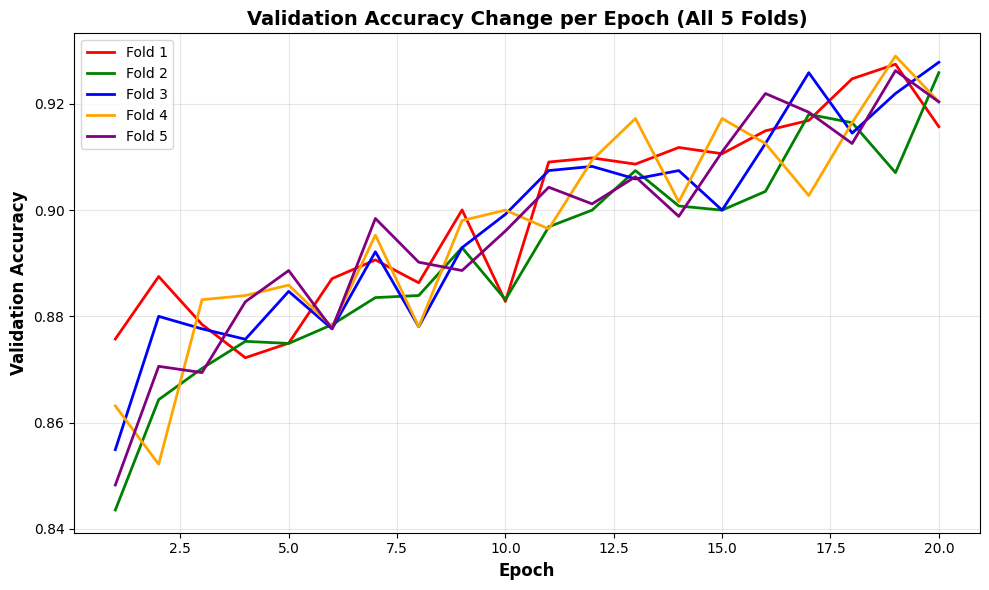

In [13]:
plt.figure(figsize=(10, 6))
colors = ['r', 'g', 'b', 'orange', 'purple']

for i, fold_data in enumerate(fold_results):
    plt.plot(range(1, len(fold_data['val_acc_history']) + 1),
             fold_data['val_acc_history'],
             label=f"Fold {fold_data['fold']}",
             color=colors[i % len(colors)],
             linewidth=2)

plt.title("Validation Accuracy Change per Epoch (All 5 Folds)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Validation Accuracy", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()